In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def apply_conversions(df, num_hum, num_mos):
    for col in ["HS", "HM", "HPC"]:
        if col in df.columns:
            df[col] = 100.0 * df[col] / num_hum

    for col in ["MS","MC", "MPC"]:
        if col in df.columns:
            df[col] = 100.0 * df[col] / num_mos

    if "PI_Humans" in df.columns:
        df["PI_Humans"] *= 100.0
    
    if "PI_Mosquitoes" in df.columns:
        df["PI_Mosquitoes"] *= 100.0
        
    if "HS" in df.columns:
        df["Human_Inf"] = 100 - df["HS"]
    
    if "MS" in df.columns:
        df["Mosquitoes_Inf"] = 100 - df["MS"]
        
    return df

def load_one_replica_final_value(filepath, metric, num_hum, num_mos, convert_to_years=True):

    df = pd.read_csv(filepath, sep=";")

    if convert_to_years and "time" in df.columns:
        df["time_years"] = df["time"] / 365.0
        xname = "time_years"
    else:
        xname = "time"

    if xname not in df.columns:
        return np.nan

    df = apply_conversions(df, num_hum=num_hum, num_mos=num_mos)   
    df = df.sort_values(xname)
    value = df.iloc[-1][metric]     
    return float(value)


def load_all_replicates_final_values(name_file, metric, num_humans, mos_x_human, convert_to_years=True):

    folder = os.path.join(".", "results/Main_Simulations", name_file)
    pattern = os.path.join(folder, "Iteration_proof_*.txt")
    files = sorted(glob.glob(pattern))

    if len(files) == 0:
        print("No hay archivos para:", name_file)
        return []

    num_mos = num_humans * mos_x_human

    vals = []
    for f in files:
        v = load_one_replica_final_value(filepath=f,
                                         metric=metric,
                                         num_hum=num_humans,
                                         num_mos=num_mos,
                                         convert_to_years=convert_to_years)
        vals.append(v)

    vals = [v for v in vals if np.isfinite(v)]
    return vals

def build_series_final_vs_br_with_error(metric,igd,lst_num_bites,
                                        num_humans,mos_x_human,convert_to_years=True,error_mode="std"):
    xs, means, errs = [], [], []

    for br in lst_num_bites:
        name_file = f"IGD_{igd}_BR_{br}_NH_{num_humans}_MxH_{mos_x_human}"
        vals = load_all_replicates_final_values(name_file=name_file,metric=metric,
                                                num_humans=num_humans,mos_x_human=mos_x_human,
                                                convert_to_years=convert_to_years)
        xs.append(br)

        if len(vals) == 0:
            means.append(np.nan)
            errs.append(np.nan)
            continue

        vals = np.array(vals, dtype=float)
        m = float(np.mean(vals))
        s = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0

        if error_mode.lower() == "sem":
            e = s / np.sqrt(len(vals)) if len(vals) > 1 else 0.0
        else:  
            e = s

        means.append(m)
        errs.append(e)

    return xs, means, errs

def plot_final_metric_vs_biting_rate_errorbars(metrics = [],
                                               figsize = None,
                                               xlabel= None, 
                                               ylabels=[],
                                               lst_init_gen_div = [], lst_num_bites= [],
                                               num_humans = None, mos_x_human = None, 
                                               convert_to_years=True, 
                                               error_mode="std", igd_colors=None, share_y = False,
                                               outdir = "./Figures/",name_fig = "Test"):
    
    
    if igd_colors is None:
        igd_colors = {10: "#B2182B",  # rojo intenso (no chillón)
                      30: "#1B9E77",  # verde/teal fuerte
                      50: "#E66101",  # naranja profundo
                      75: "#2C7FB8",  # azul medio (no pastel)
                      90: "#6A3D9A"}   # morado profundo    

    fig, ax = plt.subplots(1,2,figsize=figsize, sharey = share_y)
    
    
    for num_fig in range(2):
        if(metrics[num_fig] in ["Human_Inf", "HPC"]):
            ax[num_fig].axhline(y=100/num_humans, color='k',
                                linestyle='--', linewidth = "1", alpha = 0.5)
        
        elif(metrics[num_fig] in ["Mosquitoes_Inf", "MPC"]):
            ax[num_fig].axhline(y=100/(num_humans*mos_x_human), color='k',
                                linestyle='--', linewidth = "1", alpha = 0.5)    
        
        elif(metrics[num_fig] in ["PI_Mosquitoes", "PI_Humans"]):
            ax[num_fig].set_yticks([10,30,50,75,90])
            ax[num_fig].set_ylim([-5,95])
#             ax[num_fig].axhline(y=10, color='#B2182B', linestyle='--', linewidth = "1", alpha = 0.5)    
#             ax[num_fig].axhline(y=30, color='#1B9E77', linestyle='--', linewidth = "1", alpha = 0.5)    
#             ax[num_fig].axhline(y=50, color='#E66101', linestyle='--', linewidth = "1", alpha = 0.5)    
#             ax[num_fig].axhline(y=75, color='#2C7FB8', linestyle='--', linewidth = "1", alpha = 0.5)    
#             ax[num_fig].axhline(y=90, color='#6A3D9A', linestyle='--', linewidth = "1", alpha = 0.5)    

        for igd in lst_init_gen_div:
            xs, means, errs = build_series_final_vs_br_with_error(metric=metrics[num_fig],
                                                                  igd=igd,
                                                                  lst_num_bites=lst_num_bites,
                                                                  num_humans=num_humans,
                                                                  mos_x_human=mos_x_human,
                                                                  convert_to_years=convert_to_years,
                                                                  error_mode=error_mode)
            ax[num_fig].errorbar(xs, means, yerr=errs,
                                 color=igd_colors.get(igd, None),
                                 marker="o",linewidth=0.5, linestyle="--", capsize=5)

            ax[num_fig].scatter(xs, means, color=igd_colors[igd], label=f"{igd}%")
            
            for x, m in zip(xs, means):
                if not np.isfinite(m):
                    ax[num_fig].scatter([x], [0], marker="x",
                                        s=70, linewidths=1.5,
                                        color=igd_colors.get(igd, "black"))
            
        ax[num_fig].set_xlabel(xlabel)
        ax[num_fig].set_ylabel(ylabels[num_fig])
        ax[num_fig].grid(alpha=0.2)
        ax[num_fig].legend(title = f"$\pi_o$", fontsize = 10)
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.15)
    
    outpath = os.path.join(outdir, f"{name_fig}.png")
    plt.savefig(outpath, dpi=600, bbox_inches="tight")
    plt.show()

    return fig, ax

In [2]:
num_humans = 50
mos_x_human = 5
lst_init_gen_div = [10, 30, 50, 75, 90]
lst_num_bites = [0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 2.5, 3.0]

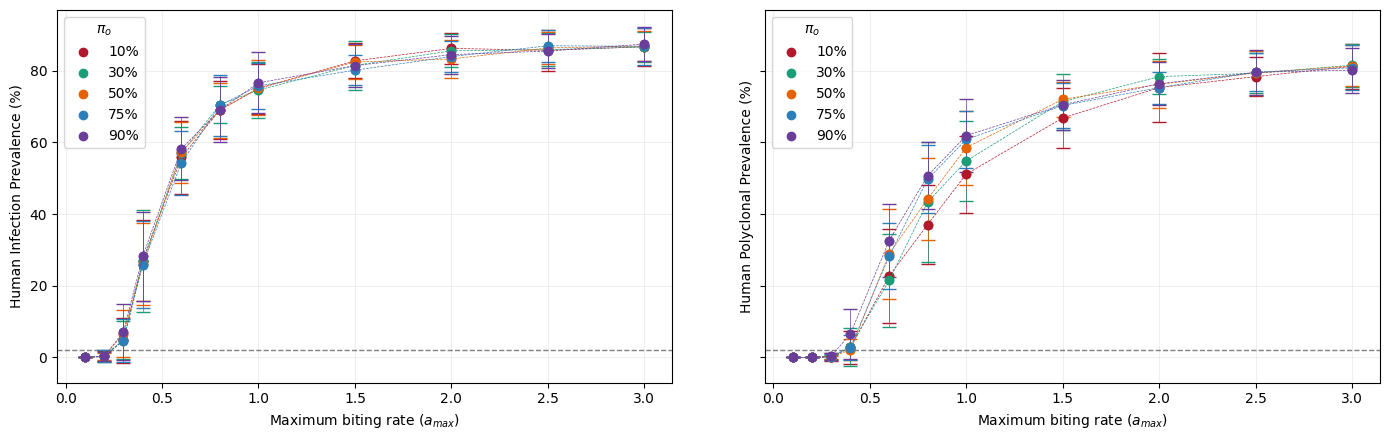

(<Figure size 1400x450 with 2 Axes>,
 array([<Axes: xlabel='Maximum biting rate $(a_{max})$', ylabel='Human Infection Prevalence (%)'>,
        <Axes: xlabel='Maximum biting rate $(a_{max})$', ylabel='Human Polyclonal Prevalence (%)'>],
       dtype=object))

In [3]:
plot_final_metric_vs_biting_rate_errorbars(metrics=["Human_Inf", "HPC"],figsize=(14, 4.5),
                                           xlabel=r"Maximum biting rate $(a_{max})$",
                                           ylabels= ["Human Infection Prevalence (%)","Human Polyclonal Prevalence (%)"] ,
                                           lst_init_gen_div=lst_init_gen_div,
                                           lst_num_bites=lst_num_bites,
                                           num_humans=num_humans,
                                           mos_x_human=mos_x_human,
                                           error_mode="std", share_y = True, name_fig = "Figure_S2A")

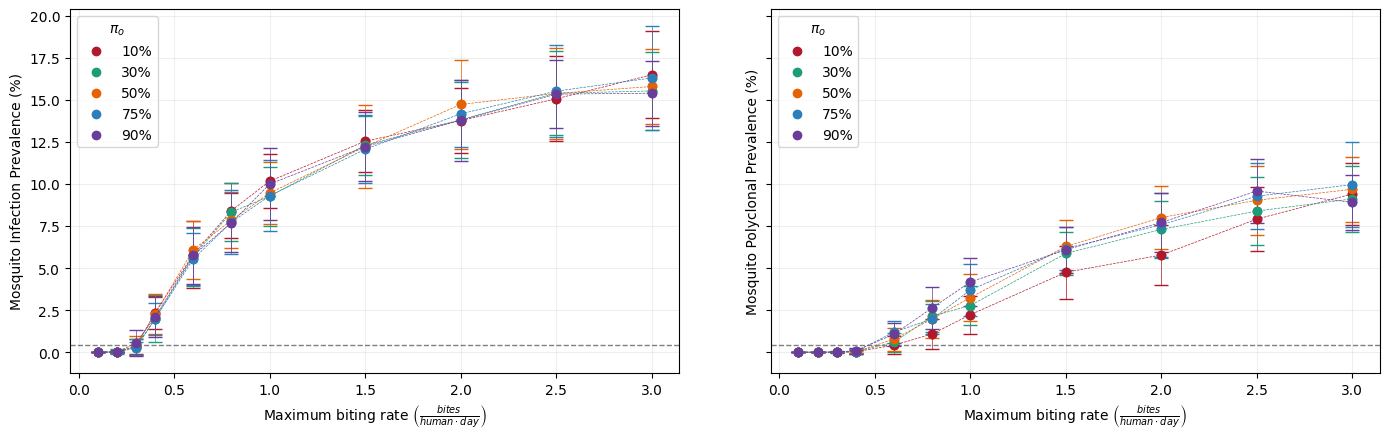

(<Figure size 1400x450 with 2 Axes>,
 array([<Axes: xlabel='Maximum biting rate $\\left(\\frac{bites}{human \\cdot day}\\right)$', ylabel='Mosquito Infection Prevalence (%)'>,
        <Axes: xlabel='Maximum biting rate $\\left(\\frac{bites}{human \\cdot day}\\right)$', ylabel='Mosquito Polyclonal Prevalence (%)'>],
       dtype=object))

In [4]:
plot_final_metric_vs_biting_rate_errorbars(metrics=["Mosquitoes_Inf", "MPC"],figsize=(14, 4.5),
                                           xlabel=r"Maximum biting rate $\left(\frac{bites}{human \cdot day}\right)$",
                                           ylabels=  ["Mosquito Infection Prevalence (%)","Mosquito Polyclonal Prevalence (%)"] ,
                                           lst_init_gen_div=lst_init_gen_div,
                                           lst_num_bites=lst_num_bites,
                                           num_humans=num_humans,
                                           mos_x_human=mos_x_human,
                                           error_mode="std", share_y = True, name_fig = "Figure_S2B")

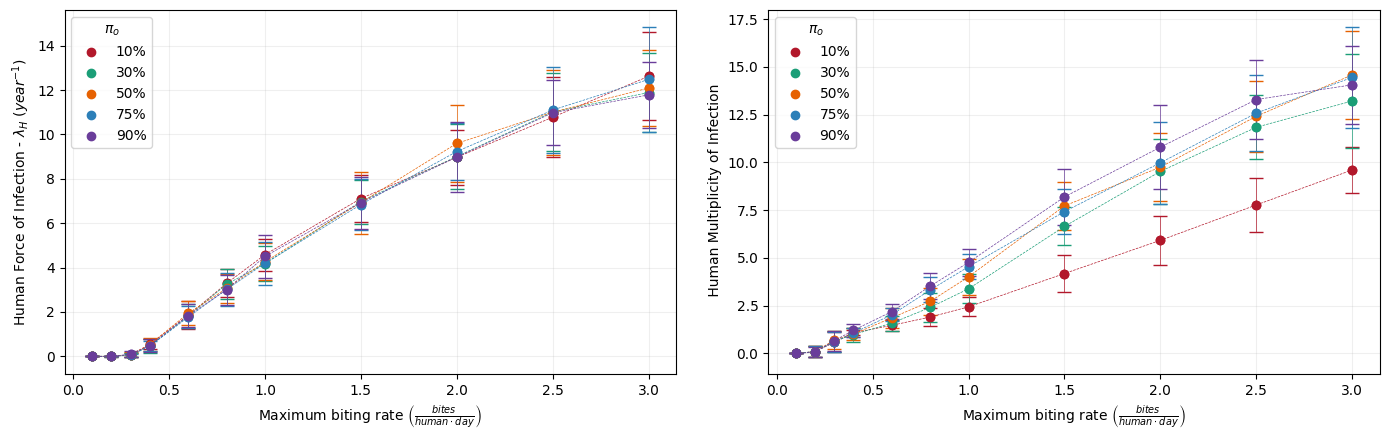

(<Figure size 1400x450 with 2 Axes>,
 array([<Axes: xlabel='Maximum biting rate $\\left(\\frac{bites}{human \\cdot day}\\right)$', ylabel='Human Force of Infection - $\\lambda_H$ $(year^{-1})$'>,
        <Axes: xlabel='Maximum biting rate $\\left(\\frac{bites}{human \\cdot day}\\right)$', ylabel=' Human Multiplicity of Infection'>],
       dtype=object))

In [5]:
plot_final_metric_vs_biting_rate_errorbars(metrics=["lambda_h", "MOI_Humans_mean"],figsize=(14, 4.5),
                                           xlabel=r"Maximum biting rate $\left(\frac{bites}{human \cdot day}\right)$",
                                           ylabels=  [r"Human Force of Infection - $\lambda_H$ $(year^{-1})$",
                                                      " Human Multiplicity of Infection"] ,
                                           lst_init_gen_div=lst_init_gen_div,
                                           lst_num_bites=lst_num_bites,
                                           num_humans=num_humans,
                                           mos_x_human=mos_x_human,
                                           error_mode="std", share_y = False, name_fig = "Figure_S3A")

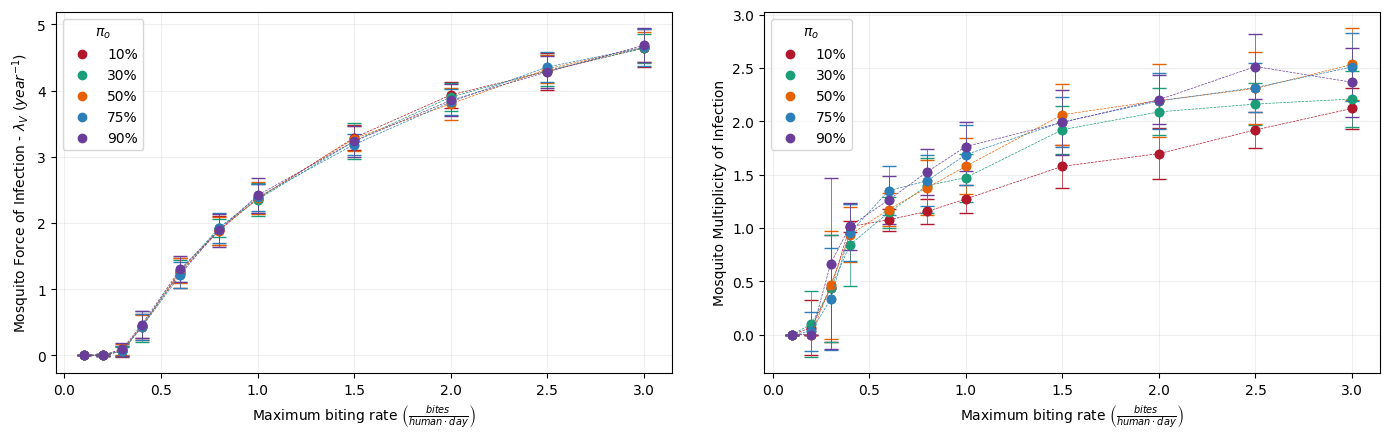

(<Figure size 1400x450 with 2 Axes>,
 array([<Axes: xlabel='Maximum biting rate $\\left(\\frac{bites}{human \\cdot day}\\right)$', ylabel='Mosquito Force of Infection - $\\lambda_V$ $(year^{-1})$'>,
        <Axes: xlabel='Maximum biting rate $\\left(\\frac{bites}{human \\cdot day}\\right)$', ylabel='Mosquito Multiplicity of Infection'>],
       dtype=object))

In [6]:
plot_final_metric_vs_biting_rate_errorbars(metrics=["lambda_v", "MOI_Mosquitoes_mean"],figsize=(14, 4.5),
                                           xlabel=r"Maximum biting rate $\left(\frac{bites}{human \cdot day}\right)$",
                                           ylabels=  [r"Mosquito Force of Infection - $\lambda_V$ $(year^{-1})$",
                                                      "Mosquito Multiplicity of Infection"] ,
                                           lst_init_gen_div=lst_init_gen_div,
                                           lst_num_bites=lst_num_bites,
                                           num_humans=num_humans,
                                           mos_x_human=mos_x_human,
                                           error_mode="std", share_y = False, name_fig = "Figure_S3B")

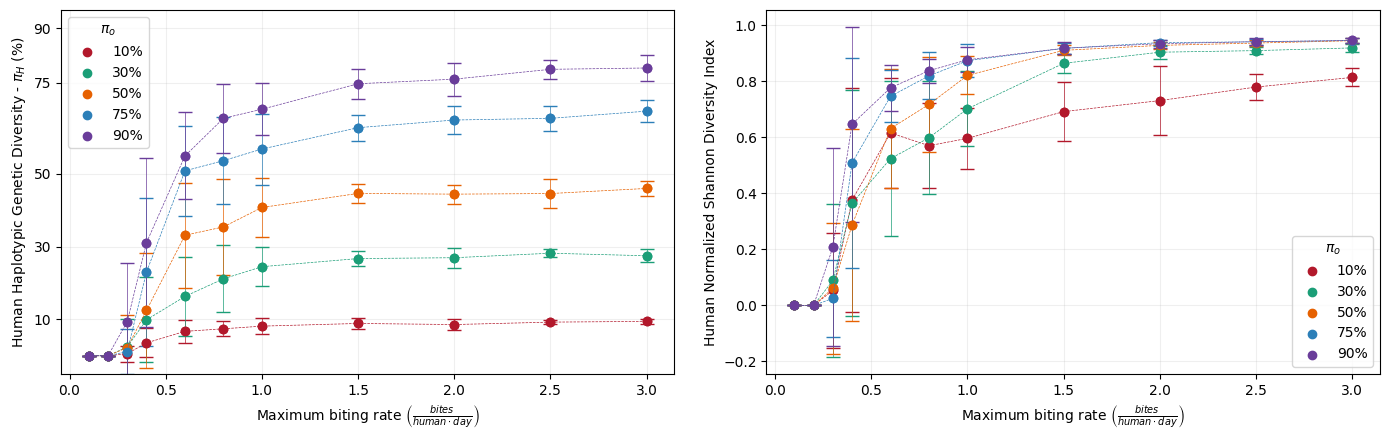

(<Figure size 1400x450 with 2 Axes>,
 array([<Axes: xlabel='Maximum biting rate $\\left(\\frac{bites}{human \\cdot day}\\right)$', ylabel='Human Haplotypic Genetic Diversity - $\\pi_H$ (%)'>,
        <Axes: xlabel='Maximum biting rate $\\left(\\frac{bites}{human \\cdot day}\\right)$', ylabel='Human Normalized Shannon Diversity Index'>],
       dtype=object))

In [7]:
plot_final_metric_vs_biting_rate_errorbars(metrics=["PI_Humans", "SH_Humans"],figsize=(14, 4.5),
                                           xlabel=r"Maximum biting rate $\left(\frac{bites}{human \cdot day}\right)$",
                                           ylabels=  [r"Human Haplotypic Genetic Diversity - $\pi_H$ (%)",
                                                      "Human Normalized Shannon Diversity Index"] ,
                                           lst_init_gen_div=lst_init_gen_div,
                                           lst_num_bites=lst_num_bites,
                                           num_humans=num_humans,
                                           mos_x_human=mos_x_human,
                                           error_mode="std", share_y = False, name_fig = "Figure_S4A")

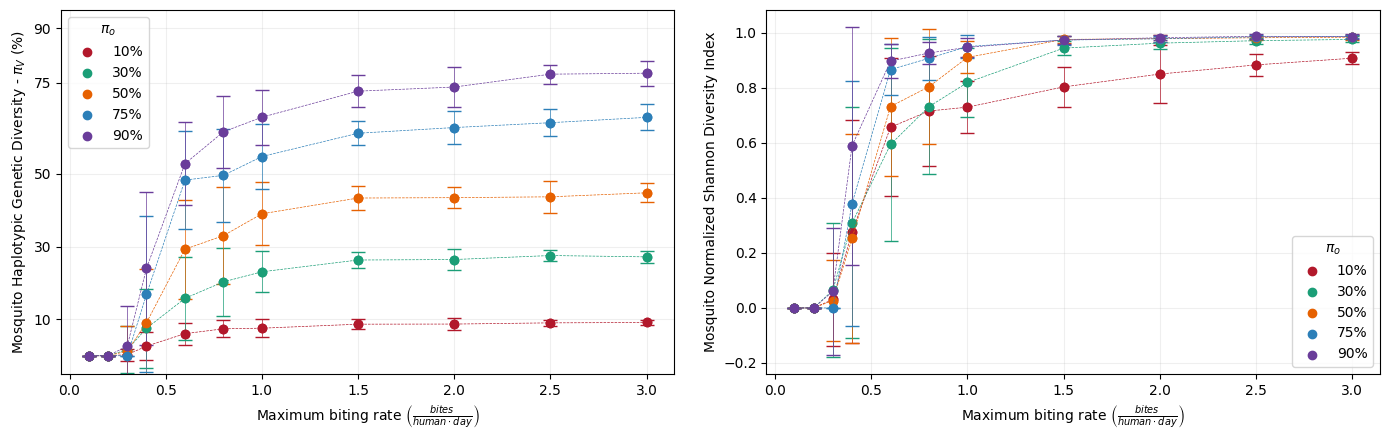

(<Figure size 1400x450 with 2 Axes>,
 array([<Axes: xlabel='Maximum biting rate $\\left(\\frac{bites}{human \\cdot day}\\right)$', ylabel='Mosquito Haplotypic Genetic Diversity - $\\pi_V$ (%)'>,
        <Axes: xlabel='Maximum biting rate $\\left(\\frac{bites}{human \\cdot day}\\right)$', ylabel='Mosquito Normalized Shannon Diversity Index'>],
       dtype=object))

In [8]:
plot_final_metric_vs_biting_rate_errorbars(metrics=["PI_Mosquitoes", "SH_Mosquitoes"],figsize=(14, 4.5),
                                           xlabel=r"Maximum biting rate $\left(\frac{bites}{human \cdot day}\right)$",
                                           ylabels=  [r"Mosquito Haplotypic Genetic Diversity - $\pi_V$ (%)",
                                                      "Mosquito Normalized Shannon Diversity Index"] ,
                                           lst_init_gen_div=lst_init_gen_div,
                                           lst_num_bites=lst_num_bites,
                                           num_humans=num_humans,
                                           mos_x_human=mos_x_human,
                                           error_mode="std", share_y = False, name_fig = "Figure_S4B")

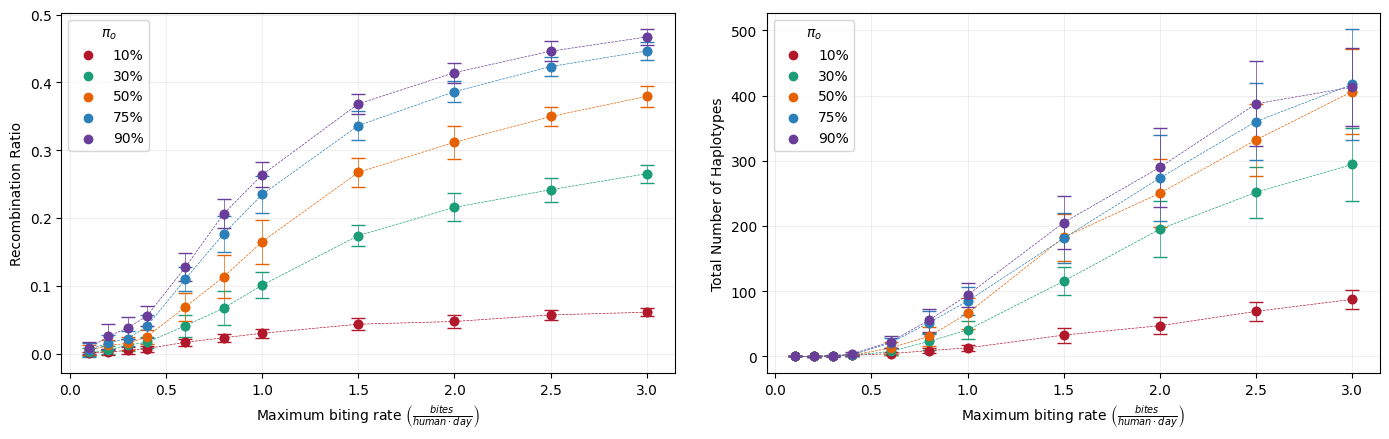

(<Figure size 1400x450 with 2 Axes>,
 array([<Axes: xlabel='Maximum biting rate $\\left(\\frac{bites}{human \\cdot day}\\right)$', ylabel='Recombination Ratio'>,
        <Axes: xlabel='Maximum biting rate $\\left(\\frac{bites}{human \\cdot day}\\right)$', ylabel='Total Number of Haplotypes'>],
       dtype=object))

In [9]:
plot_final_metric_vs_biting_rate_errorbars(metrics=["ratio_reco", "num_haplotypes"],figsize=(14, 4.5),
                                           xlabel=r"Maximum biting rate $\left(\frac{bites}{human \cdot day}\right)$",
                                           ylabels=  [r"Recombination Ratio",
                                                      "Total Number of Haplotypes"] ,
                                           lst_init_gen_div=lst_init_gen_div,
                                           lst_num_bites=lst_num_bites,
                                           num_humans=num_humans,
                                           mos_x_human=mos_x_human,
                                           error_mode="std", share_y = False, name_fig = "Figure_S5")

In [10]:
# 'time', 'HS', 'HM', 'HPC', 'MS', 'MC', 'MPC', 'ratio_reco',
#        'num_haplotypes', 'MOI_Humans_mean', 'MOI_Humans_median',
#        'MOI_Mosquitoes_mean', 'MOI_Mosquitoes_median', 'SH_Humans',
#        'SH_Mosquitoes',  , 'lambda_h', 'lambda_v'